In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

# -------------------------
# Style (matches your original essentials)
# -------------------------
plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
    "font.size": 16,
    "axes.linewidth": 1.5,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "text.usetex": True,
})

In [3]:
full_df = pd.read_csv('final_full_data_centered.csv')

In [4]:
stacked_df = pd.read_pickle('filtered_stacked_results.pkl')

In [5]:
from io import StringIO

sn2020eyj = """SN,mjd obs,flux (mJy),mjd exp date,dt (days),dt (years),redshift,Luminosity,classification,status,type
2020eyj,,,,,1.66256986301,,1.8221929931474857e+27,eyj,real,
2020eyj,,,,,2.04695342466,,1.59441886900405e+27,eyj,real,
"""

sn2020eyj_df = pd.read_csv(StringIO(sn2020eyj))

sn2020eyj_df = sn2020eyj_df.rename(columns={
    "dt (years)": "dt_years"
})

In [6]:
sn2019np_df = (
    pd.DataFrame({
        "dt_days": [2.7, 9.59, 16.94],
        "Luminosity": [9.07e24, 8.48e24, 7.33e24]
    })
    .assign(dt_years=lambda x: x["dt_days"] / 365.25)
)

In [7]:
sn2012cg_df = (
    pd.DataFrame({
        "dt_days": [4.94, 42.65, 63.65, 102.52, 155.81, 212.13],
        "Luminosity": [2.46e23, 2.76e24, 2.75e24, 5.66e23, 3.99e24, 5.81e23]
    })
    .assign(dt_years=lambda x: x["dt_days"] / 365.25)
    .sort_values("dt_years")
)

In [8]:
limits_text = """518.6739845318266, 3.5390958286868605e+27
534.2757423337531, 1.4143948280978494e+28
936.8689286179028, 9.933233229654462e+27
987.8241924399358, 9.751109888764806e+27
1133.702854036232, 9.052674280173502e+27
1087.0090205528156, 7.505883668073514e+27
968.6560672129029, 3.4822903987294616e+27
948.906571668751, 2.3945669990997227e+27
1167.670724222074, 3.8991985871946688e+28
1398.7576684890896, 2.6336765457390968e+28
1766.659820053167, 1.7792745483722697e+28
2113.983277387791, 2.447773410430409e+28
1643.3941357404458, 5.572502063638013e+27
2330.785486152451, 5.275661313616322e+27
2460.0233027683776, 2.6896096367874745e+27
2077.6664074437663, 1.9920935354006935e+27
1873.680585680004, 3.8342473984399024e+26
2415.750937737753, 3.7670263177003775e+26
3460.678103767196, 5.1861446535817246e+26
3384.774702853365, 9.985235668631153e+26
3718.3316842434524, 2.3194120347148204e+27
3446.8059242223453, 7.129333276423497e+27
4082.0649665447627, 8.286825581787916e+27
4215.604185740217, 6.258839394881287e+27
7554.058927060683, 3.197721514768506e+27
4797.513689851901, 1.427071269302816e+27
5564.593921827733, 1.3249124963099075e+27
4367.8993347421965, 5.490929807418823e+26
5175.739847246305, 4.4721317599530666e+26
9068.010696102152, 5.507258768446471e+26"""

indiv_limits_df = (
    pd.read_csv(StringIO(limits_text), header=None, names=["dt_days", "Luminosity"])
      .assign(dt_years=lambda d: d["dt_days"] / 365.25,
              name="Individual Limits",
              kind="upper_limit")
)

In [9]:
sn2012cg_long = sn2012cg_df.assign(name="SN 2012cg", kind="upper_limit")
sn2019np_long  = sn2019np_df.assign(name="SN 2019np", kind="upper_limit")

sn2020eyj_long = (
    sn2020eyj_df
      .assign(name="SN 2020eyj", kind="detection")
      .loc[:, ["name", "kind", "dt_years", "Luminosity"]]
)

# Keep only needed cols for the other two as well
sn2012cg_long = sn2012cg_long.loc[:, ["name", "kind", "dt_years", "Luminosity"]]
sn2019np_long = sn2019np_long.loc[:, ["name", "kind", "dt_years", "Luminosity"]]
indiv_limits_long = indiv_limits_df.loc[:, ["name", "kind", "dt_years", "Luminosity"]]

In [10]:
# Keep only Ia
ia_stack = stacked_df.loc[stacked_df["type"].eq("Ia")].copy()

# Convert mean delta t → years
ia_stack["dt_years"] = ia_stack["mean_delta_t"] / 365.25

# 5σ luminosity upper limit
ia_stack["Luminosity"] = 5.0 * ia_stack["rms"]

# Long-format version for unified plotting
ia_stack_long = (
    ia_stack
      .assign(name="Type Ia Stacked",
              kind="stacked_upper_limit")
      .loc[:, ["name", "kind", "dt_years", "Luminosity"]]
)

In [11]:
# --- Ia-CSM stacked ---
ia_csm_stack = stacked_df.loc[stacked_df["type"].eq("Ia-CSM")].copy()

# Use true mean delta t
ia_csm_stack["dt_years"] = ia_csm_stack["mean_delta_t"] / 365.25

# 5σ luminosity upper limit
ia_csm_stack["Luminosity"] = 5.0 * ia_csm_stack["rms"]

# Long-format for unified plotting
ia_csm_stack_long = (
    ia_csm_stack
      .assign(name="Type Ia-CSM Stacked",
              kind="stacked_upper_limit")
      .loc[:, ["name", "kind", "dt_years", "Luminosity"]]
)

In [12]:
plot_df = pd.concat(
    [sn2020eyj_long, sn2012cg_long, sn2019np_long, indiv_limits_long, ia_stack_long, ia_csm_stack_long],
    ignore_index=True
)

In [13]:
plot_df

,name,kind,dt_years,Luminosity
0,SN 2020eyj,detection,1.662570,1.822193e+27
1,SN 2020eyj,detection,2.046953,1.594419e+27
2,SN 2012cg,upper_limit,0.013525,2.460000e+23
3,SN 2012cg,upper_limit,0.116769,2.760000e+24
4,SN 2012cg,upper_limit,0.174264,2.750000e+24
5,SN 2012cg,upper_limit,0.280684,5.660000e+23
6,SN 2012cg,upper_limit,0.426585,3.990000e+24
7,SN 2012cg,upper_limit,0.580780,5.810000e+23
8,SN 2019np,upper_limit,0.007392,9.070000e+24
9,SN 2019np,upper_limit,0.026256,8.480000e+24


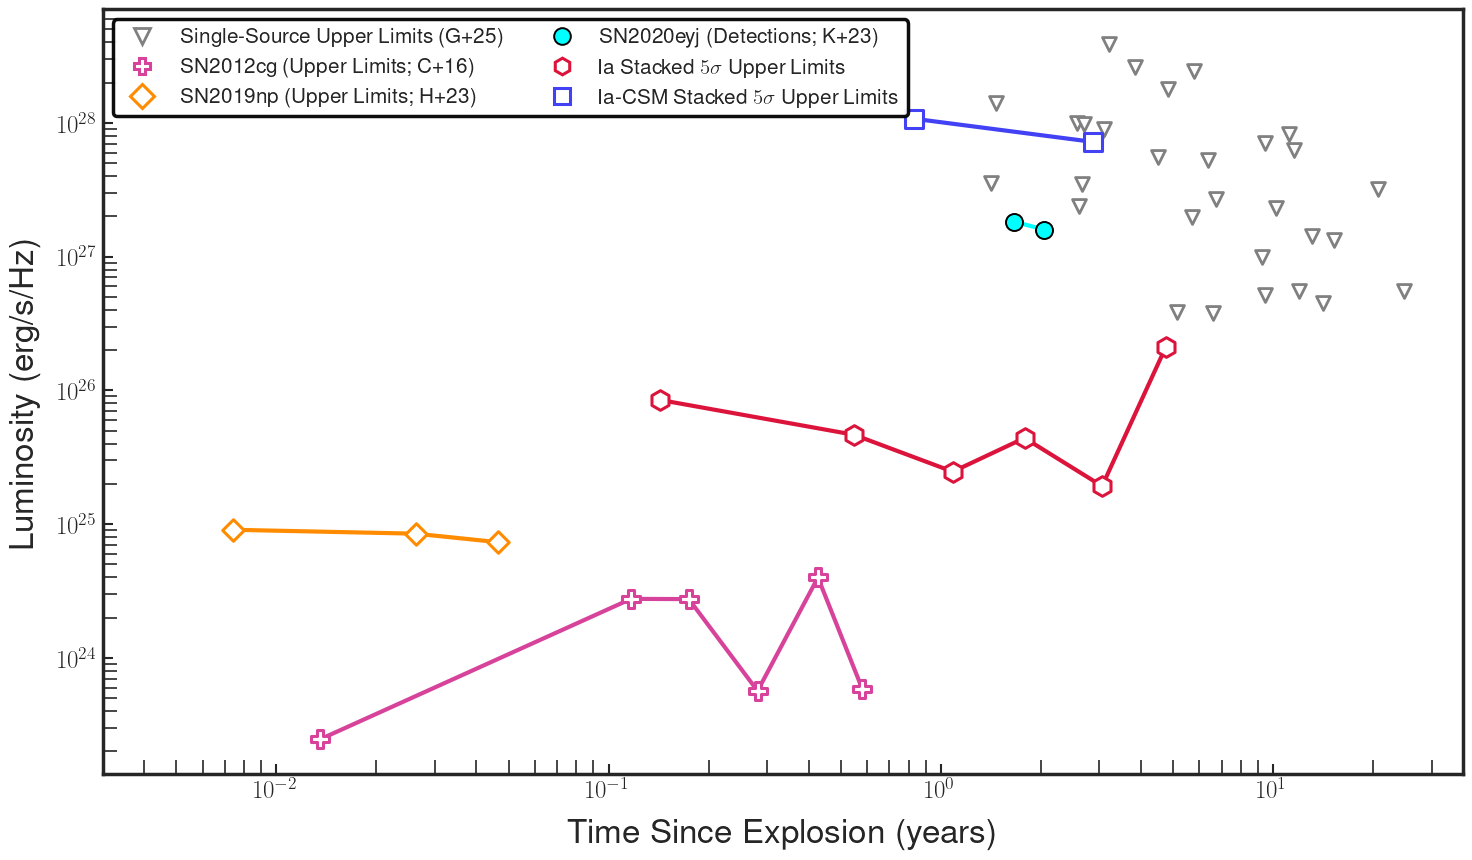

In [37]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

# 1) Style map
style_map = {
    ("Type Ia Stacked", "stacked_upper_limit"): dict(color="crimson", marker="h", s=200, lw_pt=2.2),
    ("Type Ia-CSM Stacked", "stacked_upper_limit"): dict(color="#4242F4", marker="s", s=180, lw_pt=2.2),

    ("SN 2020eyj", "detection"): dict(color="aqua", marker="o", s=150, lw_pt=2.5),
    ("SN 2012cg", "upper_limit"): dict(color="#D7439A", marker="P", s=150, lw_pt=2.2),
    ("SN 2019np", "upper_limit"): dict(color="darkorange", marker="D", s=120, lw_pt=2.2),

    ("Individual Limits", "upper_limit"): dict(color="grey", marker="v", s=100, lw_pt=2.0),
}

# Legend labels
label_map = {
    ("Type Ia Stacked", "stacked_upper_limit"):      r"Ia Stacked $5\sigma$ Upper Limits",
    ("Type Ia-CSM Stacked", "stacked_upper_limit"):  r"Ia-CSM Stacked $5\sigma$ Upper Limits",
    ("SN 2020eyj", "detection"):                     r"SN2020eyj (Detections; K+23)",
    ("SN 2012cg", "upper_limit"):                    r"SN2012cg (Upper Limits; C+16)",
    ("SN 2019np", "upper_limit"):                    r"SN2019np (Upper Limits; H+23)",
    ("Individual Limits", "upper_limit"):            r"Single-Source Upper Limits (G+25)",
}

def should_connect(name, kind):
    if name == "Individual Limits":
        return False
    return True

fig, ax = plt.subplots(figsize=(16, 9))

plot_df2 = plot_df.query("dt_years > 0 and Luminosity > 0").copy()

legend_handles = {}

for (name, kind), g in plot_df2.groupby(["name", "kind"]):
    g = g.sort_values("dt_years")
    st = style_map.get((name, kind), dict(color="gray", marker="o", s=120, lw_pt=2))

    c = st["color"]
    m = st["marker"]
    if kind == "detection":
        face_c = c
        edge_c = "black"
        lw = 1.4   # thin outline
    else:
        face_c = "white"
        edge_c = c
        lw = st["lw_pt"]
    # Single colored connecting line
    if should_connect(name, kind) and len(g) >= 2:
        ax.plot(
            g["dt_years"], g["Luminosity"],
            color=c,
            lw=3,
            zorder=2
        )

    # Points
    ax.scatter(
        g["dt_years"], g["Luminosity"],
        marker=m,
        s=st["s"],
        facecolor=face_c,
        edgecolor=edge_c,
        linewidth=lw,
        zorder=4
    )

    if (name, kind) not in legend_handles:

        label = label_map.get(
            (name, kind),
            f"{name} ({'Det.' if kind == 'detection' else 'UL'})"
        )

        legend_handles[(name, kind)] = Line2D(
            [0], [0],
            marker=m,
            color="w",
            label=label,
            markerfacecolor=face_c,
            markeredgecolor=edge_c,
            markeredgewidth=lw,
            markersize=12
        )

# Axes formatting
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(left=3e-3)

ax.set_xlabel(r"Time Since Explosion (years)", fontsize=24, labelpad=12)
ax.set_ylabel(r"Luminosity (erg/s/Hz)", fontsize=24, labelpad=12)

ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))

ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", length=10, width=1.2)

for spine in ax.spines.values():
    spine.set_linewidth(2.5)

leg = ax.legend(
    handles=list(legend_handles.values()),
    loc="upper left",
    fontsize=15,
    frameon=True,
    framealpha=0.95,
    columnspacing=1.8,
    ncol=2
)

leg.get_frame().set_linewidth(2.5)
leg.get_frame().set_edgecolor("black")

plt.subplots_adjust(bottom=0.1, left=0.1, right=0.95, top=0.95)

fig.savefig("ia_limits_plot.pdf", bbox_inches="tight")

plt.show()

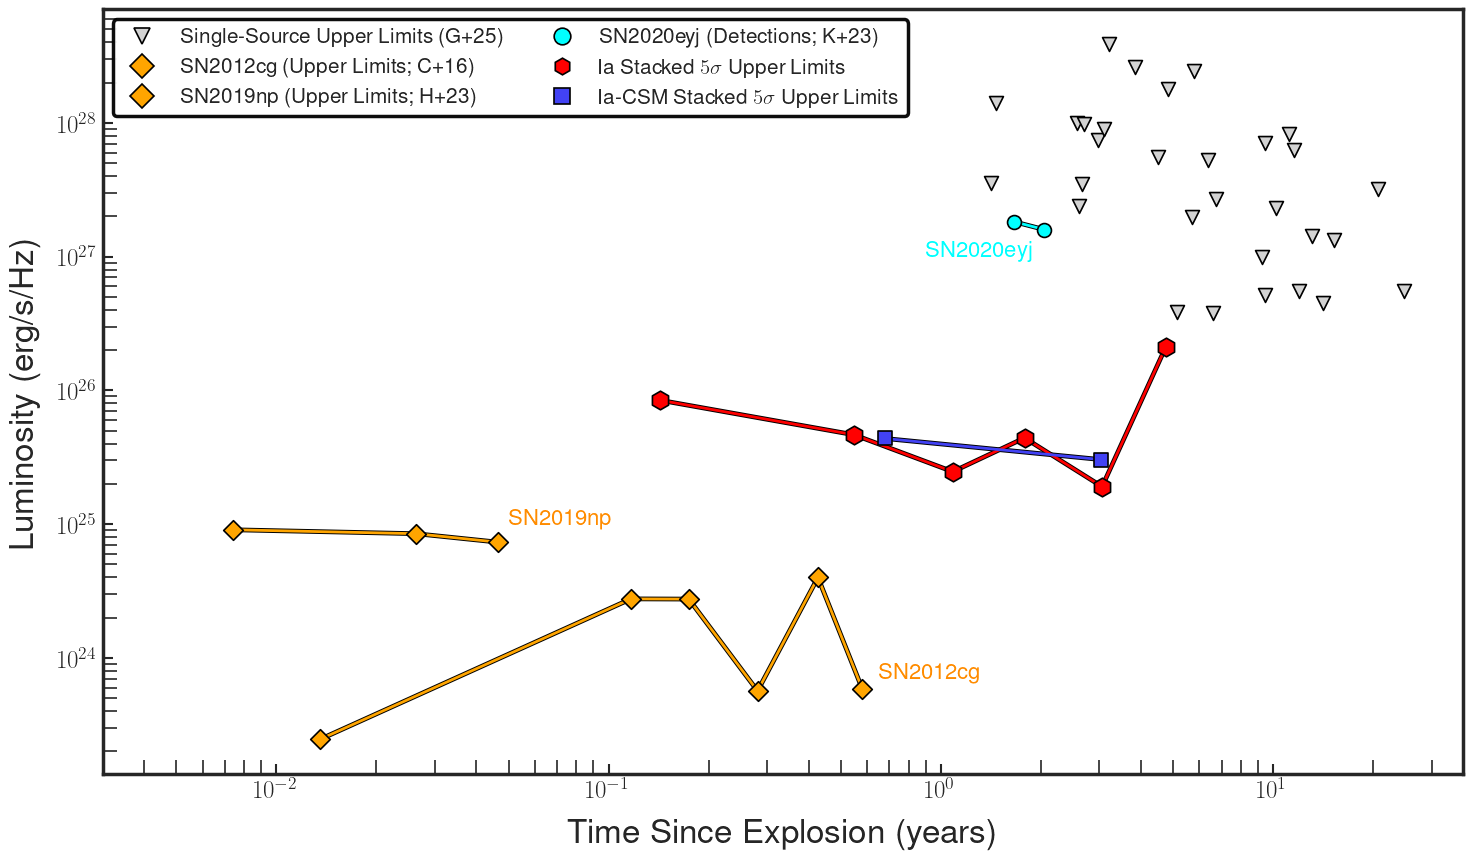

In [78]:
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
from matplotlib.lines import Line2D

# 1) Style map (edit colors/markers as you like)
style_map = {
    ("Type Ia Stacked", "stacked_upper_limit"): dict(color="red",        marker="h", s=180, lw_pt=1.2),
    ("Type Ia-CSM Stacked", "stacked_upper_limit"): dict(color="#4242F4", marker="s", s=100, lw_pt=1.2),

    ("SN 2020eyj", "detection"): dict(color="aqua",    marker="o", s=100, lw_pt=1.2),
    ("SN 2012cg",  "upper_limit"): dict(color="orange", marker="D", s=100, lw_pt=1.2),
    ("SN 2019np",  "upper_limit"): dict(color="orange", marker="D", s=100, lw_pt=1.2),

    ("Individual Limits", "upper_limit"): dict(color="lightgrey", marker="v", s=100, lw_pt=1.2),
}

# 1b) Compact legend labels (Author+YY style)
label_map = {
    ("Type Ia Stacked", "stacked_upper_limit"):      r"Ia Stacked $5\sigma$ Upper Limits",
    ("Type Ia-CSM Stacked", "stacked_upper_limit"):  r"Ia-CSM Stacked $5\sigma$ Upper Limits",
    ("SN 2020eyj", "detection"):                     r"SN2020eyj (Detections; K+23)",
    ("SN 2012cg", "upper_limit"):                    r"SN2012cg (Upper Limits; C+16)",
    ("SN 2019np", "upper_limit"):                    r"SN2019np (Upper Limits; H+23)",
    ("Individual Limits", "upper_limit"):            r"Single-Source Upper Limits (G+25)",
}

# 2) Which series should be connected?
def should_connect(name, kind):
    # don't connect the cloud of unrelated limits
    if name == "Individual Limits":
        return False
    # connect everything else (stacks + per-SN series)
    return True

# 3) Plot
fig, ax = plt.subplots(figsize=(16, 9))

plot_df2 = plot_df.query("dt_years > 0 and Luminosity > 0").copy()

legend_handles = {}

for (name, kind), g in plot_df2.groupby(["name", "kind"]):
    g = g.sort_values("dt_years")
    st = style_map.get((name, kind), dict(color="gray", marker="o", s=120, lw_pt=1.2))

    c = st["color"]
    m = st["marker"]

    # Connect SAME OBJECT points (double-line style)
    if should_connect(name, kind) and len(g) >= 2:
        ax.plot(g["dt_years"], g["Luminosity"],
                color="black", lw=3.4, zorder=2)
        ax.plot(g["dt_years"], g["Luminosity"],
                color=c, lw=2.0, zorder=3)

    # Points
    ax.scatter(g["dt_years"], g["Luminosity"],
               marker=m, s=st["s"],
               facecolor=c, edgecolor="black",
               linewidth=st["lw_pt"],
               zorder=4)

    # Legend handle (one per group)
    if (name, kind) not in legend_handles:
        label = label_map.get(
            (name, kind),
            f"{name} ({'Det.' if kind=='detection' else 'UL'})"
        )

        legend_handles[(name, kind)] = Line2D(
            [0], [0], marker=m, color="w",
            label=label,
            markerfacecolor=c,
            markeredgecolor="black",
            markeredgewidth=st["lw_pt"],
            markersize=12
        )

# Axes formatting
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(left=3e-3)

ax.set_xlabel(r"Time Since Explosion (years)", fontsize=24, labelpad=12)
ax.set_ylabel(r"Luminosity (erg/s/Hz)", fontsize=24, labelpad=12)

ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))
ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", length=10, width=1.2)

ax.text(0.65, 7e23, "SN2012cg",
        color="darkorange", fontsize=16, weight="bold")

ax.text(0.05, 1e25, "SN2019np",
        color="darkorange", fontsize=16, weight="bold")

ax.text(0.90, 1e27, "SN2020eyj",
        color="aqua", fontsize=16, weight="bold")

for spine in ax.spines.values():
    spine.set_linewidth(2.5)

leg = ax.legend(handles=list(legend_handles.values()),
                loc="upper left",
                fontsize=15, frameon=True, framealpha=0.95,
                columnspacing = 1.8, ncol = 2)
leg.get_frame().set_linewidth(2.5)
leg.get_frame().set_edgecolor("black")

plt.subplots_adjust(bottom=0.1, left=0.1, right=0.95, top=0.95)
plt.show()

KeyError: 't0_yr'

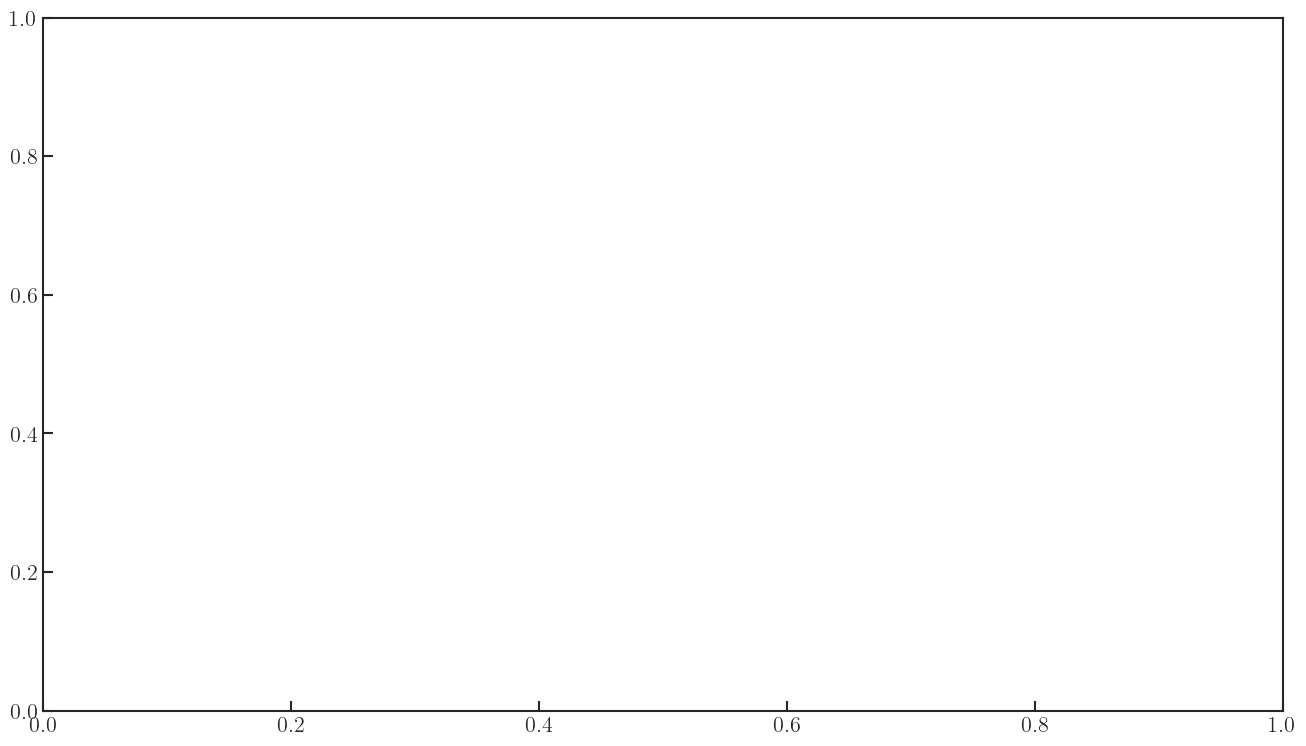

In [46]:
# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(16, 9))

ia_color = "red"
ia_csm_color = "#660099"

# --- Ia ---
for _, row in ia_stack.iterrows():
    x0, x1 = row["t0_yr"], row["t1_yr"]
    x, y   = row["t_center_yr"], row["L_upper_5sigma"]

    ax.plot([x0, x1], [y, y], color="black", lw=3.8, zorder=1)
    ax.plot([x0, x1], [y, y], color=ia_color, lw=2.2, zorder=2)
    ax.scatter(x, y, color=ia_color, marker="v", s=120,
               edgecolor="black", linewidth=1.2, zorder=3)

# --- Ia-CSM ---
for _, row in ia_csm_stack.iterrows():
    x0, x1 = row["t0_yr"], row["t1_yr"]
    x, y   = row["t_center_yr"], row["L_upper_5sigma"]

    ax.plot([x0, x1], [y, y], color="black", lw=3.8, zorder=1)
    ax.plot([x0, x1], [y, y], color=ia_csm_color, lw=2.2, zorder=2)
    ax.scatter(x, y, color=ia_csm_color, marker="s", s=120,
               edgecolor="black", linewidth=1.2, zorder=3)

# Axes scaling + limits
ax.set_xscale("log")
ax.set_yscale("log")

# set x-limits based on bin edges
xmin = max(ia_stack["t0_yr"].min() * 0.8, 1e-4)  # keep > 0 for log
xmax = ia_stack["t1_yr"].max() * 1.3
ax.set_xlim(left=9e-3)

ax.set_xlabel(r"Time Since Explosion (years)", fontsize=24, labelpad=12)
ax.set_ylabel(r"Luminosity (erg/s/Hz)", fontsize=24, labelpad=12)

# Ticks (major+minor like your original)
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))
ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", length=10, width=1.2)

# Spines + legend frame thickness like original
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

legend_elements = [
    Line2D([0], [0], marker="v", color="w",
           label=r"Type Ia Stacked $5\sigma$ Upper Limits",
           markerfacecolor=ia_color, markersize=12, markeredgecolor="black"),
]
leg = ax.legend(handles=legend_elements, loc="lower left",
                fontsize=15, frameon=True, framealpha=0.95)
leg.get_frame().set_linewidth(2.5)
leg.get_frame().set_edgecolor("black")

plt.subplots_adjust(bottom=0.1, left=0.1, right=0.95, top=0.95)
plt.show()

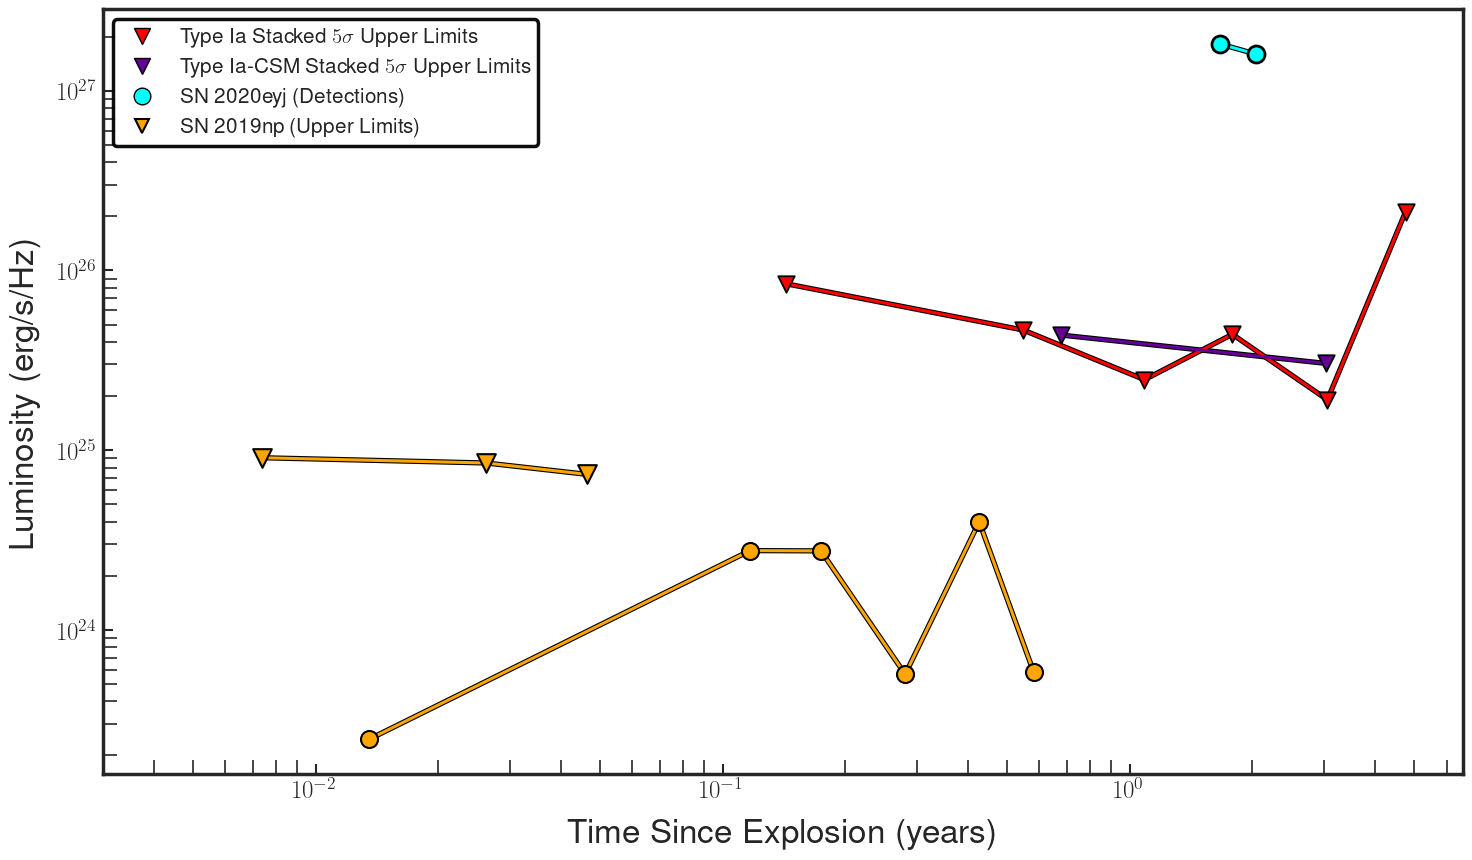

In [ ]:
# -------------------------
# Plot (Mean DeltaT + dashed connections)
# -------------------------
fig, ax = plt.subplots(figsize=(16, 9))

ia_color = "red"
ia_csm_color = "#660099"

# Convert to years if needed
ia_stack["mean_dt_yr"] = ia_stack["mean_delta_t"] / 365.25
ia_csm_stack["mean_dt_yr"] = ia_csm_stack["mean_delta_t"] / 365.25

# Drop null rows and sort
ia_plot = ia_stack.dropna(subset=["mean_dt_yr", "L_upper_5sigma"])\
                  .sort_values("mean_dt_yr")

ia_csm_plot = ia_csm_stack.dropna(subset=["mean_dt_yr", "L_upper_5sigma"])\
                          .sort_values("mean_dt_yr")

# --- Ia --- #
ax.plot(ia_plot["mean_dt_yr"],
        ia_plot["L_upper_5sigma"],
        color="black",
        linewidth=3.8,
        zorder=1)

# Colored overlay
ax.plot(ia_plot["mean_dt_yr"],
        ia_plot["L_upper_5sigma"],
        color=ia_color,
        linewidth=2.2,
        zorder=2)

ax.scatter(ia_plot["mean_dt_yr"],
           ia_plot["L_upper_5sigma"],
           marker="v",
           s=140,
           color=ia_color,
           edgecolor="black",
           linewidth=1.3,
           zorder=2)

# --- Ia-CSM --- #
ax.plot(ia_csm_plot["mean_dt_yr"],
        ia_csm_plot["L_upper_5sigma"],
        color="black",
        linewidth=3.8,
        zorder=1)

# Colored overlay
ax.plot(ia_csm_plot["mean_dt_yr"],
        ia_csm_plot["L_upper_5sigma"],
        color=ia_csm_color,
        linewidth=2.2,
        zorder=2)

ax.scatter(ia_csm_plot["mean_dt_yr"],
           ia_csm_plot["L_upper_5sigma"],
           marker="v",
           s=140,
           color=ia_csm_color,
           edgecolor="black",
           linewidth=1.3,
           zorder=2)

# --- SN2020eyj ---

ax.plot(sn2020eyj_df["dt_years"],
        sn2020eyj_df["Luminosity"],
        color="black",
        linewidth=3.8,
        zorder=4)

ax.plot(sn2020eyj_df["dt_years"],
        sn2020eyj_df["Luminosity"],
        color="aqua",
        linewidth=2.2,
        zorder=5)

ax.scatter(sn2020eyj_df["dt_years"],
           sn2020eyj_df["Luminosity"],
           marker="o",
           s=150,
           facecolor="aqua",
           edgecolor="black",
           linewidth=2,
           zorder=6,
           label="SN 2020eyj")


# --- SN2019np --- #
ax.plot(sn2019np_df["dt_years"],
        sn2019np_df["Luminosity"],
        color="black",
        linewidth=3.8,
        zorder=4)

ax.plot(sn2019np_df["dt_years"],
        sn2019np_df["Luminosity"],
        color="orange",
        linewidth=2.2,
        zorder=5)

# Points
ax.scatter(sn2019np_df["dt_years"],
           sn2019np_df["Luminosity"],
           marker="v",
           s=180,
           facecolor="orange",
           edgecolor="black",
           linewidth=1.5,
           zorder=6)

# --- SN2012cg --- # 

ax.plot(sn2012cg_df["dt_years"],
        sn2012cg_df["Luminosity"],
        color="black",
        linewidth=3.8,
        zorder=4)

ax.plot(sn2012cg_df["dt_years"],
        sn2012cg_df["Luminosity"],
        color="orange",
        linewidth=2.2,
        zorder=5)

ax.scatter(sn2012cg_df["dt_years"],
           sn2012cg_df["Luminosity"],
           marker="o",
           s=150,
           facecolor="orange",
           edgecolor="black",
           linewidth=1.5,
           zorder=6,
           label="SN 2012cg")

# Log scaling
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(left=3e-3)

ax.set_xlabel(r"Time Since Explosion (years)", fontsize=24, labelpad=12)
ax.set_ylabel(r"Luminosity (erg/s/Hz)", fontsize=24, labelpad=12)

ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))
ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", length=10, width=1.2)

for spine in ax.spines.values():
    spine.set_linewidth(2.5)

legend_elements = [
    Line2D([0], [0], marker="v", color="w",
           label=r"Type Ia Stacked $5\sigma$ Upper Limits",
           markerfacecolor=ia_color, markeredgecolor="black",
           markersize=12),

    Line2D([0], [0], marker="v", color="w",
           label=r"Type Ia-CSM Stacked $5\sigma$ Upper Limits",
           markerfacecolor=ia_csm_color, markeredgecolor="black",
           markersize=12),

    Line2D([0], [0], marker="o", color="w",
           label="SN 2020eyj (Detections)",
           markerfacecolor="aqua",
           markeredgecolor="black",
           markersize=12),

    Line2D([0], [0],
       marker="v",
       linestyle="-",
       color="white",
       label="SN 2019np (Upper Limits)",
       markerfacecolor="orange",
       markeredgecolor="black",
       markeredgewidth=1.5,
       markersize=10)
]

leg = ax.legend(handles=legend_elements, loc="upper left",
                fontsize=15, frameon=True, framealpha=0.95)
leg.get_frame().set_linewidth(2.5)
leg.get_frame().set_edgecolor("black")

plt.subplots_adjust(bottom=0.1, left=0.1, right=0.95, top=0.95)
plt.show()

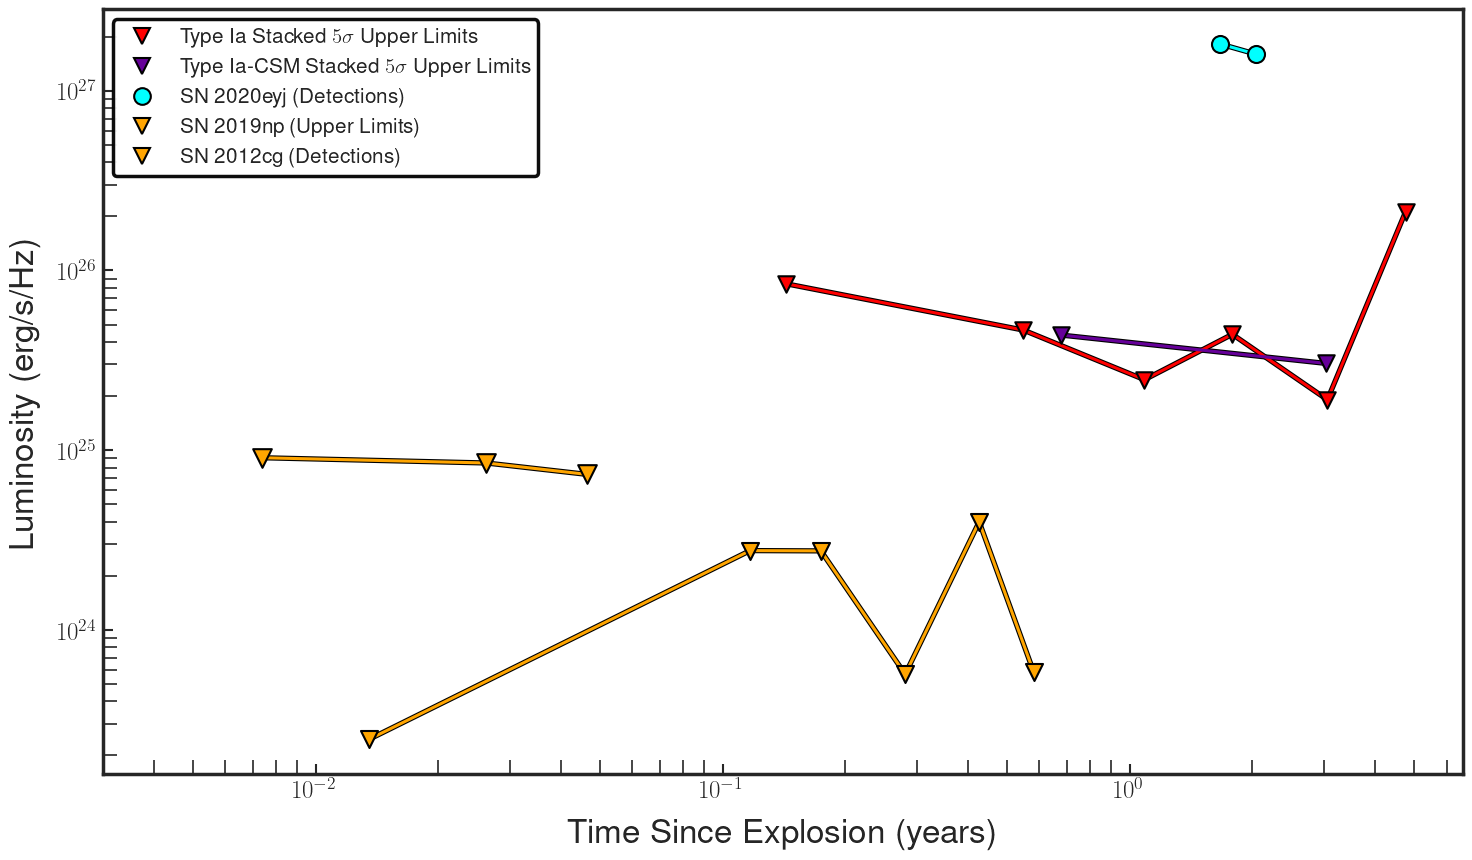

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator

# -------------------------
# Helpers
# -------------------------
def prep_stack(stack_df):
    """Add mean_dt_yr, filter nulls, sort."""
    return (stack_df.assign(mean_dt_yr=stack_df["mean_delta_t"] / 365.25)
                   .dropna(subset=["mean_dt_yr", "L_upper_5sigma"])
                   .sort_values("mean_dt_yr"))

def prep_sn(sn_df):
    """Sort by time; require positive time/lum for log axes."""
    return (sn_df.dropna(subset=["dt_years", "Luminosity"])
                .query("dt_years > 0 and Luminosity > 0")
                .sort_values("dt_years"))

def plot_double_line(ax, x, y, color, *, lw_black=3.8, lw_color=2.2, z=1, linestyle="-"):
    ax.plot(x, y, color="black", lw=lw_black, ls=linestyle, zorder=z)
    ax.plot(x, y, color=color,  lw=lw_color, ls=linestyle, zorder=z+1)

def plot_points(ax, x, y, *, marker, facecolor, edgecolor="black", s=150, lw=1.5, z=3):
    ax.scatter(x, y, marker=marker, s=s, facecolor=facecolor,
               edgecolor=edgecolor, linewidth=lw, zorder=z)

# -------------------------
# Styles + what to plot
# -------------------------
styles = {
    "Ia_stack":     dict(color="red",     marker="v", s=140, lw_pt=1.5, z_line=1, z_pt=3),
    "IaCSM_stack":  dict(color="#660099", marker="v", s=140, lw_pt=1.5, z_line=1, z_pt=3),

    "SN2020eyj":    dict(color="aqua",   marker="o", s=150, lw_pt=1.5, z_line=4, z_pt=6),
    "SN2019np":     dict(color="orange", marker="v", s=180, lw_pt=1.5, z_line=4, z_pt=6),
    "SN2012cg":     dict(color="orange", marker="v", s=150, lw_pt=1.5, z_line=4, z_pt=6),
}

# “Series config” like your groupby loop:
# key -> (kind, dataframe, xcol, ycol, legend_label)
series = [
    ("Ia_stack",    "stack", ia_stack,     "mean_dt_yr", "L_upper_5sigma", r"Type Ia Stacked $5\sigma$ Upper Limits"),
    ("IaCSM_stack", "stack", ia_csm_stack, "mean_dt_yr", "L_upper_5sigma", r"Type Ia-CSM Stacked $5\sigma$ Upper Limits"),

    ("SN2020eyj",   "sn",    sn2020eyj_df, "dt_years",   "Luminosity",     "SN 2020eyj (Detections)"),
    ("SN2019np",    "sn",    sn2019np_df,  "dt_years",   "Luminosity",     "SN 2019np (Upper Limits)"),
    ("SN2012cg",    "sn",    sn2012cg_df,  "dt_years",   "Luminosity",     "SN 2012cg (Detections)"),
]

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(16, 9))

legend_handles = []  # build legend programmatically

for key, kind, df0, xcol, ycol, leg_label in series:
    st = styles[key]

    # prep
    if kind == "stack":
        dfp = prep_stack(df0)
    else:
        dfp = prep_sn(df0)

    x = dfp[xcol]
    y = dfp[ycol]

    # double-line connection (outline style)
    plot_double_line(ax, x, y, st["color"],
                     lw_black=3.8, lw_color=2.2,
                     z=st["z_line"],
                     linestyle=st.get("linestyle", "-"))

    # points
    plot_points(ax, x, y,
                marker=st["marker"],
                facecolor=st["color"],
                s=st["s"],
                lw=st["lw_pt"],
                z=st["z_pt"])

    # legend handle (marker-only, like your examples)
    legend_handles.append(
        Line2D([0], [0],
               marker=st["marker"],
               color="w",
               label=leg_label,
               markerfacecolor=st["color"],
               markeredgecolor="black",
               markeredgewidth=st["lw_pt"],
               markersize=12)
    )

# -------------------------
# Axes styling (same as yours)
# -------------------------
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(left=3e-3)

ax.set_xlabel(r"Time Since Explosion (years)", fontsize=24, labelpad=12)
ax.set_ylabel(r"Luminosity (erg/s/Hz)", fontsize=24, labelpad=12)

ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))
ax.tick_params(axis="both", which="major", labelsize=18)
ax.tick_params(axis="both", which="minor", length=10, width=1.2)

for spine in ax.spines.values():
    spine.set_linewidth(2.5)

leg = ax.legend(handles=legend_handles, loc="upper left",
                fontsize=15, frameon=True, framealpha=0.95)
leg.get_frame().set_linewidth(2.5)
leg.get_frame().set_edgecolor("black")

plt.subplots_adjust(bottom=0.1, left=0.1, right=0.95, top=0.95)
plt.show()

In [11]:
import traceback

try:
    plt.show()
except Exception:
    traceback.print_exc()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_transient_epochs_flux(df, name,
                               name_col="Name",
                               epoch_col="Epoch",
                               path_col="File Path",
                               rms_col="RMS_mjy",
                               peak_col="Flux_mjy",
                               dt_col="Rest_DeltaT",
                               cmap="inferno",
                               border_snr_threshold=4,
                               border_color="lime",
                               savepath=None):
    """
    Plot all available epochs for a transient in a single row,
    using stored RMS and Peak FLUX columns (does NOT recompute).

    Formatting matches your luminosity plot:
      - Title: Name, Epoch, Δt
      - X label: RMS, Max Flux, S/N
      - Lime border if S/N > threshold
    """

    g = df[df[name_col] == name].copy()
    if len(g) == 0:
        raise ValueError(f"No rows found for object '{name}'")

    g = g.sort_values(epoch_col)
    n = len(g)

    fig, axs = plt.subplots(1, n, figsize=(4*n, 4), constrained_layout=True)
    if n == 1:
        axs = [axs]

    fig.suptitle(name, fontsize=14)

    for ax, (_, row) in zip(axs, g.iterrows()):
        path = row[path_col]

        if not os.path.exists(path):
            ax.set_title("Missing file")
            ax.axis("off")
            continue

        arr = np.load(path)

        rms = row[rms_col]
        peak = row[peak_col]
        snr = peak / rms if rms != 0 else np.nan

        epoch = row[epoch_col]
        delta_t = row.get(dt_col, np.nan)

        ax.imshow(arr, cmap=cmap, interpolation="nearest")

        ax.set_title(
            f"{name}: Epoch {epoch}, Δt: {delta_t:.0f}d",
            fontsize=9
        )

        ax.set_xlabel(
        "RMS: {:.3g} mJy, Max Flux: {:.3g} mJy\nS/N: {:.3f}".format(rms, peak, snr),
        fontsize=9
)

        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)

        if np.isfinite(snr) and snr > border_snr_threshold:
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(4)
        else:
            for spine in ax.spines.values():
                spine.set_edgecolor("black")
                spine.set_linewidth(1)

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    plt.show()
    return fig, axs

In [13]:
plot_transient_epochs_flux(full_df, 'ZTF21abviabc')

RuntimeError: latex was not able to process the following string:
b'ZTF21abviabc: Epoch 1, \\u0394t: -1284d'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.2) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/psnfss\helvet.sty
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/graphics\keyval.sty))
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/type1cm\type1cm.sty)
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/cm-super\type1ec.sty
(C:\Users\kerbe\AppData\Local\Prog

<Figure size 1200x400 with 3 Axes>

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'ZTF21abviabc: Epoch 1, Δt: -1284d'}, xlabel='RMS: 0.126 mJy, Max Flux: 0.773 mJy\nS/N: 6.129'>,
        <Axes: title={'center': 'ZTF21abviabc: Epoch 2, Δt: -298d'}, xlabel='RMS: 0.164 mJy, Max Flux: 0.84 mJy\nS/N: 5.118'>,
        <Axes: title={'center': 'ZTF21abviabc: Epoch 3, Δt: 546d'}, xlabel='RMS: 0.357 mJy, Max Flux: 4.54 mJy\nS/N: 12.710'>],
       dtype=object))

In [14]:
plot_transient_epochs_flux(full_df, 'ZTF19aakswrb')

RuntimeError: latex was not able to process the following string:
b'ZTF19aakswrb: Epoch 1, \\u0394t: 33d'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.29 (MiKTeX 26.2) (preloaded format=latex.fmt)
 restricted \write18 enabled.
entering extended mode
(file.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/base\article.cls
Document Class: article 2025/01/22 v1.4n Standard LaTeX document class
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/base\size10.clo))
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/psnfss\helvet.sty
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/graphics\keyval.sty))
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/type1cm\type1cm.sty)
(C:\Users\kerbe\AppData\Local\Programs\MiKTeX\tex/latex/cm-super\type1ec.sty
(C:\Users\kerbe\AppData\Local\Program

<Figure size 1200x400 with 3 Axes>

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'ZTF19aakswrb: Epoch 1, Δt: 33d'}, xlabel='RMS: 0.144 mJy, Max Flux: -0.0497 mJy\nS/N: -0.345'>,
        <Axes: title={'center': 'ZTF19aakswrb: Epoch 2, Δt: 920d'}, xlabel='RMS: 0.199 mJy, Max Flux: 0.212 mJy\nS/N: 1.068'>,
        <Axes: title={'center': 'ZTF19aakswrb: Epoch 3, Δt: 1741d'}, xlabel='RMS: 0.129 mJy, Max Flux: 0.757 mJy\nS/N: 5.857'>],
       dtype=object))